In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os

# Pascal VOC 2007
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar

# Pascal VOC 2012
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

# Extract
!tar -xf VOCtrainval_06-Nov-2007.tar
!tar -xf VOCtest_06-Nov-2007.tar
!tar -xf VOCtrainval_11-May-2012.tar

--2026-05-07 15:15:35--  http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 

129.67.94.50
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.50|:80... 

connected.
HTTP request sent, awaiting response... 

301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar [following]
--2026-05-07 15:15:36--  https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 

129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... 

...

y-2012.tar           98%[==================> ]   1.83G  36.9MB/s    eta 2s     

-2012.tar            98%[==================> ]   1.84G  36.9MB/s    eta 2s     

2012.tar             99%[==================> ]   1.85G  36.8MB/s    eta 0s     

012.tar              99%[==================> ]   1.85G  36.7MB/s    eta 0s     

VOCtrainval_11-May- 100%[===================>]   1.86G  36.8MB/s    in 54s     

2026-05-07 15:17:00 (35.1 MB/s) - ‘VOCtrainval_11-May-2012.tar’ saved [1999639040/1999639040]



In [3]:
# All 20 Pascal VOC classes (order matters — index = class_id)
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

class_to_id = {cls: idx for idx, cls in enumerate(VOC_CLASSES)}
print(class_to_id)

{'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4, 'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9, 'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14, 'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19}


In [4]:
import xml.etree.ElementTree as ET
import os

def voc_to_yolo(xml_path, output_dir, class_to_id):
    """Convert a single VOC XML annotation to YOLO .txt format."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Image dimensions
    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)

    yolo_lines = []

    for obj in root.findall('object'):
        class_name = obj.find('name').text.strip()

        # Skip classes not in our list
        if class_name not in class_to_id:
            print(class_name)
            continue

        # Skip difficult objects (optional)
        difficult = obj.find('difficult')
        if difficult is not None and int(difficult.text) == 1:
            continue

        class_id = class_to_id[class_name]

        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        # Convert to YOLO format (normalized)
        x_center = (xmin + xmax) / 2 / img_w
        y_center = (ymin + ymax) / 2 / img_h
        width    = (xmax - xmin) / img_w
        height   = (ymax - ymin) / img_h

        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    # Save .txt file with same name as XML
    filename = os.path.splitext(os.path.basename(xml_path))[0]
    out_path = os.path.join(output_dir, filename + '.txt')

    with open(out_path, 'w') as f:
        f.write('\n'.join(yolo_lines))

In [5]:
from pathlib import Path
from tqdm import tqdm

def convert_dataset(voc_root, output_label_dir):
    """Convert all XML annotations in a VOC dataset folder."""
    ann_dir = os.path.join(voc_root, 'Annotations')
    os.makedirs(output_label_dir, exist_ok=True)

    xml_files = list(Path(ann_dir).glob('*.xml'))
    print(f"Found {len(xml_files)} annotation files in {voc_root}")

    for xml_path in tqdm(xml_files):
        voc_to_yolo(str(xml_path), output_label_dir, class_to_id)

    print(f"✅ Done! Labels saved to: {output_label_dir}")

# Step 2: Re-run conversion with correct VOCdevkit paths
convert_dataset(
    voc_root='/kaggle/working/VOCdevkit/VOC2007',
    output_label_dir='/kaggle/working/yolo_labels/VOC2007'
)

convert_dataset(
    voc_root='/kaggle/working/VOCdevkit/VOC2012',
    output_label_dir='/kaggle/working/yolo_labels/VOC2012'
)

Found 9963 annotation files in /kaggle/working/VOCdevkit/VOC2007


  0%|          | 0/9963 [00:00<?, ?it/s]

  6%|▌         | 580/9963 [00:00<00:01, 5789.91it/s]

 12%|█▏        | 1160/9963 [00:00<00:01, 5788.39it/s]

 17%|█▋        | 1739/9963 [00:00<00:01, 5699.15it/s]

...

 88%|████████▊ | 15076/17125 [00:02<00:00, 7054.97it/s]

 92%|█████████▏| 15782/17125 [00:02<00:00, 6991.52it/s]

 96%|█████████▌| 16482/17125 [00:02<00:00, 6963.76it/s]

100%|██████████| 17125/17125 [00:02<00:00, 6811.15it/s]

✅ Done! Labels saved to: /kaggle/working/yolo_labels/VOC2012


In [6]:
classes_path = '/kaggle/working/yolo_labels/classes.txt'
with open(classes_path, 'w') as f:
    f.write('\n'.join(VOC_CLASSES))

print("classes.txt created:")
!cat /kaggle/working/yolo_labels/classes.txt

classes.txt created:
aeroplane
bicycle
bird
boat
bottle
bus
car
cat
chair
cow
diningtable
dog
horse
motorbike
person
pottedplant
sheep
sofa
train
tvmonitor

In [7]:
import random

# Step 3: Verify labels now exist
label_files = list(Path('/kaggle/working/yolo_labels/VOC2007').glob('*.txt'))
print(f"Total label files: {len(label_files)}")  # Should be ~5000+

sample = random.choice(label_files)
print(f"File: {sample.name}")
print(open(sample).read())

# Expected output format:
# 14 0.512000 0.430000 0.340000 0.612000
# class_id  x_ctr    y_ctr    width    height

Total label files: 9963
File: 002124.txt
17 0.809000 0.825826 0.286000 0.348348
8 0.621000 0.677177 0.178000 0.309309
19 0.219000 0.591592 0.118000 0.156156


In [8]:
yaml_content = f"""
train: /kaggle/working/VOC/VOC2007/JPEGImages
val:   /kaggle/working/VOC/VOC2012/JPEGImages

nc: 20  # number of classes
names: {VOC_CLASSES}
"""

with open('/kaggle/working/yolo_labels/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created ✅")

data.yaml created ✅


In [9]:
import shutil
import os

# Zip the yolo_labels folder
shutil.make_archive(
    base_name='/kaggle/working/voc_yolo_labels',  # output zip name
    format='zip',
    root_dir='/kaggle/working',
    base_dir='yolo_labels'
)

# Also zip VOCdevkit if you want raw images too
shutil.make_archive(
    base_name='/kaggle/working/VOCdevkit_full',
    format='zip',
    root_dir='/kaggle/working',
    base_dir='VOCdevkit'
)

print("Files saved:")
!ls -lh /kaggle/working/*.zip

Files saved:
-rw-r--r-- 1 root root 2.7G May  7 15:18 /kaggle/working/VOCdevkit_full.zip
-rw-r--r-- 1 root root 5.0M May  7 15:17 /kaggle/working/voc_yolo_labels.zip


In [10]:
import os

# Clone official YOLOv9 repository
!git clone https://github.com/WongKinYiu/yolov9.git
%cd yolov9

# Verify structure
!ls

Cloning into 'yolov9'...


remote: Enumerating objects: 781, done.


remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 16.58 MiB/s, done.
Resolving deltas: 100% (330/330), done.


/kaggle/working/yolov9
benchmarks.py	export.py   panoptic	      tools	       val_dual.py
classify	figure	    README.md	      train_dual.py    val.py
data		hubconf.py  requirements.txt  train.py	       val_triple.py
detect_dual.py	LICENSE.md  scripts	      train_triple.py
detect.py	models	    segment	      utils


In [11]:
!pip install -r requirements.txt -q


In [12]:
!pip install torch torchvision

In [13]:
import torch 
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
import os

# print( os.listdir('/kaggle/working/VOCdevkit/VOC2007'))
# print( os.listdir('/kaggle/working/VOCdevkit/VOC2007/JPEGImages') ) 


! cd ..


In [15]:
%cd yolov9

[Errno 2] No such file or directory: 'yolov9'
/kaggle/working/yolov9


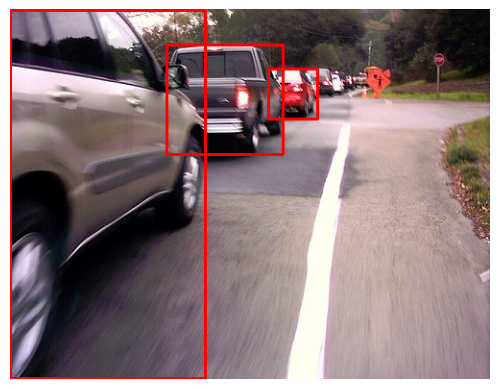

In [16]:
import cv2
import matplotlib.pyplot as plt

# image path
img_path = "/kaggle/working/VOCdevkit/VOC2007/JPEGImages/004203.jpg"

# YOLO label path
label_path = "/kaggle/working/yolo_labels/VOC2007/004203.txt"

# read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

# read labels
with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:
    cls, x, y, bw, bh = map(float, line.split())

    # convert YOLO -> pixel coords
    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    # draw box
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

# show image
plt.imshow(img)
plt.axis("off")
plt.show()

In [17]:
label2012 = "/kaggle/working/yolo_labels/VOC2012"
label2007 = "/kaggle/working/yolo_labels/VOC2007"

print(len(os.listdir(label2012)))
print(len(os.listdir(label2007)))

17125
9963


In [18]:
img2012 = '/kaggle/working/VOCdevkit/VOC2012/JPEGImages'
img2007 = '/kaggle/working/VOCdevkit/VOC2007/JPEGImages'

print(len(os.listdir(img2012)))
print(len(os.listdir(img2007)))

17125
9963


In [19]:
# We'll write this into models/attention.py so yolov9 can import it

attention_code = '''
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    """
    Channel Attention Module (from CBAM).
    Learns WHICH feature channels are important.
    """
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 8)  # avoid bottleneck too small

        self.avg_pool = nn.AdaptiveAvgPool2d(1)  # squeeze H,W -> 1x1
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # shared MLP across avg and max branch
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))   # avg branch
        max_out = self.mlp(self.max_pool(x))   # max branch
        scale   = self.sigmoid(avg_out + max_out)  # combine
        return x * scale                           # re-weight channels


class C2f_CA(nn.Module):
    """
    C2f block (already in yolov9) wrapped with Channel Attention at the end.
    We'll register this so the YAML config can call it by name.
    """
    def __init__(self, c1, c2, n=1, shortcut=False, g=1, e=0.5):
        super().__init__()
        from models.common import C2f          # yolov9's existing block
        self.c2f = C2f(c1, c2, n, shortcut, g, e)
        self.ca  = ChannelAttention(c2)

    def forward(self, x):
        return self.ca(self.c2f(x))
'''

# Write to file
with open('models/attention.py', 'w') as f:
    f.write(attention_code)

print("✅ models/attention.py created")

✅ models/attention.py created


In [20]:
# Read the current parse_model function
with open('models/yolo.py', 'r') as f:
    content = f.read()

# Find the import block and add ours
old_line = "from models.common import *"
new_line  = "from models.common import *\nfrom models.attention import ChannelAttention, C2f_CA"

if "from models.attention" not in content:
    content = content.replace(old_line, new_line)
    with open('models/yolo.py', 'w') as f:
        f.write(content)
    print("✅ Registered attention modules in models/yolo.py")
else:
    print("ℹ️ Already registered")

✅ Registered attention modules in models/yolo.py


In [21]:
import glob

yamls = glob.glob('models/**/*.yaml', recursive=True)
for y in yamls:
    print(y)

models/segment/yolov7-af-seg.yaml
models/segment/yolov9-c-dseg.yaml
models/segment/gelan-c-seg.yaml
models/segment/gelan-c-dseg.yaml
models/hub/yolov3-spp.yaml
models/hub/yolov3.yaml
models/hub/yolov3-tiny.yaml
models/hub/anchors.yaml
models/detect/yolov9-t.yaml
models/detect/yolov9-cf.yaml
models/detect/gelan-s.yaml
models/detect/yolov7-af.yaml
models/detect/gelan-t.yaml
models/detect/gelan-c.yaml
models/detect/yolov9-e.yaml
models/detect/gelan.yaml
models/detect/gelan-m.yaml
models/detect/yolov9-m.yaml
models/detect/yolov9-c.yaml
models/detect/gelan-e.yaml
models/detect/yolov9-s.yaml
models/detect/yolov9.yaml
models/panoptic/yolov7-af-pan.yaml
models/panoptic/gelan-c-pan.yaml


In [22]:
with open('models/detect/gelan-c.yaml', 'r') as f:
    content = f.read()

print(content)

# YOLOv9

# parameters
nc: 80  # number of classes
depth_multiple: 1.0  # model depth multiple
width_multiple: 1.0  # layer channel multiple
#activation: nn.LeakyReLU(0.1)
#activation: nn.ReLU()

# anchors
anchors: 3

# gelan backbone
backbone:
  [
   # conv down
   [-1, 1, Conv, [64, 3, 2]],  # 0-P1/2

   # conv down
   [-1, 1, Conv, [128, 3, 2]],  # 1-P2/4

   # elan-1 block
   [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]],  # 2

   # avg-conv down
   [-1, 1, ADown, [256]],  # 3-P3/8

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]],  # 4

   # avg-conv down
   [-1, 1, ADown, [512]],  # 5-P4/16

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 6

   # avg-conv down
   [-1, 1, ADown, [512]],  # 7-P5/32

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 8
  ]

# gelan head
head:
  [
   # elan-spp block
   [-1, 1, SPPELAN, [512, 256]],  # 9

   # up-concat merge
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 6], 1, Concat, [1]],  # ca

In [23]:
new_yaml = """# YOLOv9 + Channel Attention (gelan-c-ca.yaml)

# parameters
nc: 80  # number of classes
depth_multiple: 1.0
width_multiple: 1.0

# anchors
anchors: 3

# gelan backbone with Channel Attention after deep stages
backbone:
  [
   # conv down
   [-1, 1, Conv, [64, 3, 2]],             # 0-P1/2

   # conv down
   [-1, 1, Conv, [128, 3, 2]],            # 1-P2/4

   # elan-1 block
   [-1, 1, RepNCSPELAN4, [256, 128, 64, 1]],  # 2

   # avg-conv down
   [-1, 1, ADown, [256]],                 # 3-P3/8

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 256, 128, 1]],  # 4
   # >>> Channel Attention after P3 stage
   [-1, 1, ChannelAttention, [512]],      # 5  ← NEW

   # avg-conv down
   [-1, 1, ADown, [512]],                 # 6-P4/16

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 7
   # >>> Channel Attention after P4 stage
   [-1, 1, ChannelAttention, [512]],      # 8  ← NEW

   # avg-conv down
   [-1, 1, ADown, [512]],                 # 9-P5/32

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 10
   # >>> Channel Attention after P5 stage
   [-1, 1, ChannelAttention, [512]],      # 11  ← NEW
  ]

# gelan head  (layer indices shifted by +3 due to new CA layers)
head:
  [
   # elan-spp block
   [-1, 1, SPPELAN, [512, 256]],          # 12

   # up-concat merge
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 8], 1, Concat, [1]],             # 14 - cat backbone P4 (was 6, now 8)

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 15

   # up-concat merge
   [-1, 1, nn.Upsample, [None, 2, 'nearest']],
   [[-1, 5], 1, Concat, [1]],             # 17 - cat backbone P3 (was 4, now 5)

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]],  # 18 (P3/8-small)

   # avg-conv-down merge
   [-1, 1, ADown, [256]],
   [[-1, 15], 1, Concat, [1]],            # cat head P4

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 21 (P4/16-medium)

   # avg-conv-down merge
   [-1, 1, ADown, [512]],
   [[-1, 12], 1, Concat, [1]],            # cat head P5

   # elan-2 block
   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 24 (P5/32-large)

   # detect
   [[18, 21, 24], 1, DDetect, [nc]],      # DDetect(P3, P4, P5)
  ]
"""

with open('models/detect/gelan-c-ca.yaml', 'w') as f:
    f.write(new_yaml)

print("✅ gelan-c-ca.yaml saved")

✅ gelan-c-ca.yaml saved


In [24]:
import torch
from models.yolo import Model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Model('models/detect/gelan-c-ca.yaml', ch=3, nc=80).to(device)
print("✅ Model built successfully!")

# count parameters
total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total parameters: {total:.2f}M")


                 from  n    params  module                                  arguments                     


  0                -1  1      1856  models.common.Conv                      [3, 64, 3, 2]                 


  1                -1  1     73984  models.common.Conv                      [64, 128, 3, 2]               


  2                -1  1    212864  models.common.RepNCSPELAN4              [128, 256, 128, 64, 1]        


  3                -1  1    164352  models.common.ADown                     [256, 256]                    


...

 23          [-1, 12]  1         0  models.common.Concat                    [1]                           


 24                -1  1   3119616  models.common.RepNCSPELAN4              [1024, 512, 512, 256, 1]      


 25      [18, 21, 24]  1   5552320  models.yolo.DDetect                     [80, [256, 512, 512]]         


gelan-c-ca summary: 645 layers, 25597056 parameters, 25597040 gradients, 103.7 GFLOPs


✅ Model built successfully!
Total parameters: 25.60M


In [25]:
# Let's see exactly which layers are CA and confirm shapes
print("=" * 60)
print("Architecture Summary — Key Layers")
print("=" * 60)

layer_info = [
    (0,  "Conv",              "3→64",   "Initial stem"),
    (1,  "Conv",              "64→128",  "Downsample"),
    (2,  "RepNCSPELAN4",      "128→256", "P2 stage"),
    (3,  "ADown",             "256→256", "Downsample P3"),
    (4,  "RepNCSPELAN4",      "256→512", "P3 stage"),
    (5,  "ChannelAttention ✨","512→512", "← CA added here"),
    (6,  "ADown",             "512→512", "Downsample P4"),
    (7,  "RepNCSPELAN4",      "512→512", "P4 stage"),
    (8,  "ChannelAttention ✨","512→512", "← CA added here"),
    (9,  "ADown",             "512→512", "Downsample P5"),
    (10, "RepNCSPELAN4",      "512→512", "P5 stage"),
    (11, "ChannelAttention ✨","512→512", "← CA added here"),
    (12, "SPPELAN",           "512→512", "SPP (multi-scale)"),
    (15, "RepNCSPELAN4",      "1024→512","Head P4 fusion"),
    (18, "RepNCSPELAN4",      "1024→256","Head P3 fusion"),
    (21, "RepNCSPELAN4",      "768→512", "Head P4 out"),
    (24, "RepNCSPELAN4",      "1024→512","Head P5 out"),
    (25, "DDetect",           "P3+P4+P5","Final detection"),
]

for idx, name, channels, note in layer_info:
    marker = " ◄◄◄" if "✨" in name else ""
    print(f"  Layer {idx:>2} | {name:<22} | {channels:<10} | {note}{marker}")

print("=" * 60)
print(f"\nCA adds only 3x32,768 = 98,304 params on top of base model")
print(f"Base gelan-c ≈ 25.5M  →  gelan-c-ca = 25.60M  (+0.38% only)")

Architecture Summary — Key Layers
  Layer  0 | Conv                   | 3→64       | Initial stem
  Layer  1 | Conv                   | 64→128     | Downsample
  Layer  2 | RepNCSPELAN4           | 128→256    | P2 stage
  Layer  3 | ADown                  | 256→256    | Downsample P3
  Layer  4 | RepNCSPELAN4           | 256→512    | P3 stage
  Layer  5 | ChannelAttention ✨     | 512→512    | ← CA added here ◄◄◄
  Layer  6 | ADown                  | 512→512    | Downsample P4
  Layer  7 | RepNCSPELAN4           | 512→512    | P4 stage
  Layer  8 | ChannelAttention ✨     | 512→512    | ← CA added here ◄◄◄
  Layer  9 | ADown                  | 512→512    | Downsample P5
  Layer 10 | RepNCSPELAN4           | 512→512    | P5 stage
  Layer 11 | ChannelAttention ✨     | 512→512    | ← CA added here ◄◄◄
  Layer 12 | SPPELAN                | 512→512    | SPP (multi-scale)
  Layer 15 | RepNCSPELAN4           | 1024→512   | Head P4 fusion
  Layer 18 | RepNCSPELAN4           | 1024→256   | Head P

In [26]:
# VOC has 20 classes — update the model config
import yaml

# First let's set nc=20 for VOC
with open('models/detect/gelan-c-ca.yaml', 'r') as f:
    cfg = f.read()

cfg = cfg.replace('nc: 80', 'nc: 20')

with open('models/detect/gelan-c-ca.yaml', 'w') as f:
    f.write(cfg)

# Now create the VOC data yaml
voc_classes = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

data_yaml = {
    'path': '/kaggle/working',
    'train': 'images/train',
    'val':   'images/val',
    'nc':    20,
    'names': voc_classes
}

with open('voc_ca.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("✅ nc set to 20 for VOC")
print("✅ voc_ca.yaml created")
print("\nClasses:", voc_classes)

✅ nc set to 20 for VOC
✅ voc_ca.yaml created

Classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [27]:
import os
print(os.listdir('/kaggle/working'))

['VOCtest_06-Nov-2007.tar', 'yolo_labels', 'VOCdevkit_full.zip', '__notebook__.ipynb', 'VOCtrainval_06-Nov-2007.tar', 'voc_yolo_labels.zip', 'VOCdevkit', 'yolov9', 'VOCtrainval_11-May-2012.tar']


In [28]:
import os

# Check image folders
print("=== IMAGE FOLDERS ===")
print("VOC2012 images:", len(os.listdir('/kaggle/working/VOCdevkit/VOC2012/JPEGImages')))
print("VOC2007 images:", len(os.listdir('/kaggle/working/VOCdevkit/VOC2007/JPEGImages')))

print("\n=== LABEL FOLDERS ===")
print("Labels 2012:", len(os.listdir('/kaggle/working/yolo_labels/VOC2012')))
print("Labels 2007:", len(os.listdir('/kaggle/working/yolo_labels/VOC2007')))

print("\n=== SAMPLE LABEL (first file) ===")
first_label = os.listdir('/kaggle/working/yolo_labels/VOC2012')[0]
with open(f'/kaggle/working/yolo_labels/VOC2012/{first_label}') as f:
    print(f.read())

=== IMAGE FOLDERS ===
VOC2012 images: 17125
VOC2007 images: 9963

=== LABEL FOLDERS ===
Labels 2012: 17125
Labels 2007: 9963

=== SAMPLE LABEL (first file) ===
14 0.510000 0.641333 0.844000 0.717333


In [29]:
import os, random

random.seed(42)

all_images = []

# Collect all image paths from both years
for year, img_dir, lbl_dir in [
    ('VOC2012',
     '/kaggle/working/VOCdevkit/VOC2012/JPEGImages',
     '/kaggle/working/yolo_labels/VOC2012'),
    ('VOC2007',
     '/kaggle/working/VOCdevkit/VOC2007/JPEGImages',
     '/kaggle/working/yolo_labels/VOC2007'),
]:
    for fname in os.listdir(img_dir):
        stem = os.path.splitext(fname)[0]
        lbl  = os.path.join(lbl_dir, stem + '.txt')
        img  = os.path.join(img_dir, fname)
        # only add if label exists
        if os.path.exists(lbl):
            all_images.append(img)

random.shuffle(all_images)

split       = int(0.9 * len(all_images))
train_imgs  = all_images[:split]
val_imgs    = all_images[split:]

# Write txt files yolov9 expects
with open('/kaggle/working/train.txt', 'w') as f:
    f.write('\n'.join(train_imgs))

with open('/kaggle/working/val.txt', 'w') as f:
    f.write('\n'.join(val_imgs))

print(f"✅ Train images : {len(train_imgs)}")
print(f"✅ Val   images : {len(val_imgs)}")
print(f"\nSample train path:\n  {train_imgs[0]}")

✅ Train images : 24379
✅ Val   images : 2709

Sample train path:
  /kaggle/working/VOCdevkit/VOC2012/JPEGImages/2008_004615.jpg


In [30]:
import yaml

voc_classes = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

data_yaml = {
    'train' : '/kaggle/working/train.txt',
    'val'   : '/kaggle/working/val.txt',
    'nc'    : 20,
    'names' : voc_classes
}

with open('/kaggle/working/voc_ca.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("✅ voc_ca.yaml written")
print("\nContent:")
with open('/kaggle/working/voc_ca.yaml') as f:
    print(f.read())

✅ voc_ca.yaml written

Content:
train: /kaggle/working/train.txt
val: /kaggle/working/val.txt
nc: 20
names:
- aeroplane
- bicycle
- bird
- boat
- bottle
- bus
- car
- cat
- chair
- cow
- diningtable
- dog
- horse
- motorbike
- person
- pottedplant
- sheep
- sofa
- train
- tvmonitor



In [31]:
import os

for year in ['VOC2012', 'VOC2007']:
    # Where yolov9 will look for labels
    link_path = f'/kaggle/working/VOCdevkit/{year}/labels'
    # Where your labels actually live
    real_path = f'/kaggle/working/yolo_labels/{year}'

    # Remove if broken link exists
    if os.path.islink(link_path):
        os.remove(link_path)
        print(f"🔄 Removed old link: {link_path}")

    os.symlink(real_path, link_path)
    print(f"✅ {link_path}")
    print(f"   → {real_path}")
    print(f"   Files visible: {len(os.listdir(link_path))}")
    print()

✅ /kaggle/working/VOCdevkit/VOC2012/labels
   → /kaggle/working/yolo_labels/VOC2012
   Files visible: 17125

✅ /kaggle/working/VOCdevkit/VOC2007/labels
   → /kaggle/working/yolo_labels/VOC2007
   Files visible: 9963



In [32]:
import os

for year in ['VOC2012', 'VOC2007']:
    img_dir = f'/kaggle/working/VOCdevkit/{year}/JPEGImages'
    
    # pick one sample
    sample_jpg = os.listdir(img_dir)[0]
    img_path   = f'{img_dir}/{sample_jpg}'
    
    # THIS is exactly how yolov9 derives the label path internally
    derived_lbl = img_path.replace('/JPEGImages/', '/labels/') \
                          .replace('.jpg', '.txt')
    
    print(f"[{year}]")
    print(f"  Image  : {img_path}")
    print(f"  Label  : {derived_lbl}")
    print(f"  Exists : {os.path.exists(derived_lbl)} ✅" 
          if os.path.exists(derived_lbl) 
          else f"  Exists : False ❌")
    print()

[VOC2012]
  Image  : /kaggle/working/VOCdevkit/VOC2012/JPEGImages/2010_005985.jpg
  Label  : /kaggle/working/VOCdevkit/VOC2012/labels/2010_005985.txt
  Exists : True ✅

[VOC2007]
  Image  : /kaggle/working/VOCdevkit/VOC2007/JPEGImages/004938.jpg
  Label  : /kaggle/working/VOCdevkit/VOC2007/labels/004938.txt
  Exists : True ✅



In [33]:
import os

for year in ['VOC2012', 'VOC2007']:
    base = f'/kaggle/working/VOCdevkit/{year}'
    
    # 1. images symlink: VOC2012/images → VOC2012/JPEGImages
    img_link = f'{base}/images'
    img_real = f'{base}/JPEGImages'
    if os.path.islink(img_link):
        os.remove(img_link)
    os.symlink(img_real, img_link)
    
    # 2. labels symlink: VOC2012/labels → /kaggle/working/yolo_labels/VOC2012
    lbl_link = f'{base}/labels'
    lbl_real = f'/kaggle/working/yolo_labels/{year}'
    if os.path.islink(lbl_link):
        os.remove(lbl_link)
    os.symlink(lbl_real, lbl_link)
    
    print(f"✅ {year}")
    print(f"   images → {img_real}  ({len(os.listdir(img_link))} files)")
    print(f"   labels → {lbl_real}  ({len(os.listdir(lbl_link))} files)")
    print()

✅ VOC2012
   images → /kaggle/working/VOCdevkit/VOC2012/JPEGImages  (17125 files)
   labels → /kaggle/working/yolo_labels/VOC2012  (17125 files)

✅ VOC2007
   images → /kaggle/working/VOCdevkit/VOC2007/JPEGImages  (9963 files)
   labels → /kaggle/working/yolo_labels/VOC2007  (9963 files)



In [34]:
import os, random

random.seed(42)
all_images = []

for year in ['VOC2012', 'VOC2007']:
    # NOW using /images/ path so yolov9 can derive /labels/
    img_dir = f'/kaggle/working/VOCdevkit/{year}/images'
    lbl_dir = f'/kaggle/working/VOCdevkit/{year}/labels'

    for fname in os.listdir(img_dir):
        if not fname.endswith('.jpg'):
            continue
        stem = os.path.splitext(fname)[0]
        if os.path.exists(f'{lbl_dir}/{stem}.txt'):
            all_images.append(f'{img_dir}/{fname}')

random.shuffle(all_images)
split = int(0.9 * len(all_images))

with open('/kaggle/working/train.txt', 'w') as f:
    f.write('\n'.join(all_images[:split]))
with open('/kaggle/working/val.txt', 'w') as f:
    f.write('\n'.join(all_images[split:]))

print(f"✅ Train: {len(all_images[:split])}")
print(f"✅ Val  : {len(all_images[split:])}")

# ── Critical check: simulate exactly what dataloaders.py does ─────
import os
sample = all_images[0]
sa = f'{os.sep}images{os.sep}'
sb = f'{os.sep}labels{os.sep}'
derived = sb.join(sample.rsplit(sa, 1)).rsplit('.', 1)[0] + '.txt'

print(f"\nSample image : {sample}")
print(f"Derived label: {derived}")
print(f"Label exists : {os.path.exists(derived)}")

# show label content
if os.path.exists(derived):
    with open(derived) as f:
        print(f"\nLabel content:\n{f.read()}")

✅ Train: 24379
✅ Val  : 2709

Sample image : /kaggle/working/VOCdevkit/VOC2012/images/2008_004615.jpg
Derived label: /kaggle/working/VOCdevkit/VOC2012/labels/2008_004615.txt
Label exists : True

Label content:
13 0.497000 0.501333 0.946000 0.997333
13 0.353000 0.388000 0.702000 0.770667
13 0.304000 0.244000 0.604000 0.482667
15 0.947000 0.134667 0.106000 0.264000


In [35]:
import os

# Check what nc is currently in the yaml
with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml') as f:
    content = f.read()

print("Current yaml head (first 5 lines):")
for line in content.split('\n')[:6]:
    print(' ', line)

# Fix: make sure nc=20
if 'nc: 80' in content:
    content = content.replace('nc: 80', 'nc: 20')
    with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml', 'w') as f:
        f.write(content)
    print("\n✅ Fixed nc: 80 → nc: 20")
else:
    print("\nCurrent nc setting:")
    for line in content.split('\n'):
        if 'nc' in line:
            print(' ', line)

Current yaml head (first 5 lines):
  # YOLOv9 + Channel Attention (gelan-c-ca.yaml)
  
  # parameters
  nc: 20  # number of classes
  depth_multiple: 1.0
  width_multiple: 1.0

Current nc setting:
  nc: 20  # number of classes
  # anchors
  anchors: 3
     # up-concat merge
     [[-1, 8], 1, Concat, [1]],             # 14 - cat backbone P4 (was 6, now 8)
     # up-concat merge
     [[-1, 5], 1, Concat, [1]],             # 17 - cat backbone P3 (was 4, now 5)
     [[-1, 15], 1, Concat, [1]],            # cat head P4
     [[-1, 12], 1, Concat, [1]],            # cat head P5
     [[18, 21, 24], 1, DDetect, [nc]],      # DDetect(P3, P4, P5)


In [36]:
import os, shutil

# Delete caches
for c in ['/kaggle/working/train.cache', '/kaggle/working/val.cache']:
    if os.path.exists(c):
        os.remove(c)
        print(f"🗑️  {c}")

# Delete the broken run folders so there's no stale state
runs_dir = '/kaggle/working/runs'
if os.path.exists(runs_dir):
    shutil.rmtree(runs_dir)
    print(f"🗑️  {runs_dir}")

print("\n✅ Clean slate ready")

# Double-check both yamls agree on nc=20
print("\n--- gelan-c-ca.yaml ---")
with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml') as f:
    for line in f.readlines()[:4]:
        print(' ', line, end='')

print("\n--- voc_ca.yaml ---")
with open('/kaggle/working/voc_ca.yaml') as f:
    import yaml
    d = yaml.safe_load(f)
    print(f"  nc: {d['nc']}")
    print(f"  names: {d['names']}")


✅ Clean slate ready

--- gelan-c-ca.yaml ---
  # YOLOv9 + Channel Attention (gelan-c-ca.yaml)
  
  # parameters
  nc: 20  # number of classes

--- voc_ca.yaml ---
  nc: 20
  names: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [37]:
import subprocess

# Search all relevant files for nc=80 or nc: 80
result = subprocess.run(
    ['grep', '-rn', 'nc', 
     '/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml',
     '/kaggle/working/voc_ca.yaml',
    ],
    capture_output=True, text=True
)
print("=== YAML files ===")
print(result.stdout)

# Also check if there's a cached compiled model somewhere
result2 = subprocess.run(
    ['find', '/kaggle/working/runs', '-name', '*.yaml'],
    capture_output=True, text=True
)
print("=== Run yamls (may have stale nc=80) ===")
print(result2.stdout)

# Read each found yaml
for path in result2.stdout.strip().split('\n'):
    if path:
        print(f"\n--- {path} ---")
        with open(path) as f:
            for line in f:
                if 'nc' in line:
                    print(' ', line, end='')

=== YAML files ===
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:4:nc: 20  # number of classes
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:8:# anchors
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:9:anchors: 3
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:54:   # up-concat merge
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:56:   [[-1, 8], 1, Concat, [1]],             # 14 - cat backbone P4 (was 6, now 8)
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:61:   # up-concat merge
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:63:   [[-1, 5], 1, Concat, [1]],             # 17 - cat backbone P3 (was 4, now 5)
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:70:   [[-1, 15], 1, Concat, [1]],            # cat head P4
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:77:   [[-1, 12], 1, Concat, [1]],            # cat head P5
/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml:83:   [[18, 21, 24], 1, DDetect, [nc]],      # DDetect(P3, P4, P

In [38]:
import sys, os
sys.path.insert(0, '/kaggle/working/yolov9')
os.chdir('/kaggle/working/yolov9')

import torch
from models.yolo import Model

model = Model('models/detect/gelan-c-ca.yaml', ch=3, nc=20)

# Find the Detect head
for name, m in model.named_modules():
    if hasattr(m, 'nc') or hasattr(m, 'no'):
        nc  = getattr(m, 'nc',  'N/A')
        no  = getattr(m, 'no',  'N/A')
        cls = m.__class__.__name__
        print(f"{cls:30s} | nc={nc} | no={no}")


                 from  n    params  module                                  arguments                     


  0                -1  1      1856  models.common.Conv                      [3, 64, 3, 2]                 


  1                -1  1     73984  models.common.Conv                      [64, 128, 3, 2]               


  2                -1  1    212864  models.common.RepNCSPELAN4              [128, 256, 128, 64, 1]        


  3                -1  1    164352  models.common.ADown                     [256, 256]                    


...

 23          [-1, 12]  1         0  models.common.Concat                    [1]                           


 24                -1  1   3119616  models.common.RepNCSPELAN4              [1024, 512, 512, 256, 1]      


 25      [18, 21, 24]  1   5506060  models.yolo.DDetect                     [20, [256, 512, 512]]         


gelan-c-ca summary: 645 layers, 25550796 parameters, 25550780 gradients, 103.4 GFLOPs


DDetect                        | nc=20 | no=84


In [39]:
with open('/kaggle/working/yolov9/models/yolo.py', 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if 'self.no' in line:
        start = max(0, i-2)
        end   = min(len(lines), i+4)
        print(f"--- Line {i+1} ---")
        for j in range(start, end):
            print(f"{j+1}: {lines[j]}", end='')
        print()

--- Line 43 ---
41:         self.nl = len(ch)  # number of detection layers
42:         self.reg_max = 16
43:         self.no = nc + self.reg_max * 4  # number of outputs per anchor
44:         self.inplace = inplace  # use inplace ops (e.g. slice assignment)
45:         self.stride = torch.zeros(self.nl)  # strides computed during build
46: 

--- Line 64 ---
62:             self.shape = shape
63: 
64:         box, cls = torch.cat([xi.view(shape[0], self.no, -1) for xi in x], 2).split((self.reg_max * 4, self.nc), 1)
65:         dbox = dist2bbox(self.dfl(box), self.anchors.unsqueeze(0), xywh=True, dim=1) * self.strides
66:         y = torch.cat((dbox, cls.sigmoid()), 1)
67:         return y if self.export else (y, x)

--- Line 92 ---
90:         self.nl = len(ch)  # number of detection layers
91:         self.reg_max = 16
92:         self.no = nc + self.reg_max * 4  # number of outputs per anchor
93:         self.inplace = inplace  # use inplace ops (e.g. slice assignment)
94:         s

In [40]:
with open('/kaggle/working/yolov9/models/yolo.py', 'r') as f:
    content = f.read()

print("Searching for 'no =' in DDetect class...")
for i, line in enumerate(content.split('\n')):
    if 'self.no' in line or ('no ' in line and 'DDetect' in content.split('\n')[max(0,i-20):i+1][-1]):
        print(f"  Line {i+1}: {line}")

Searching for 'no =' in DDetect class...
  Line 43:         self.no = nc + self.reg_max * 4  # number of outputs per anchor
  Line 64:         box, cls = torch.cat([xi.view(shape[0], self.no, -1) for xi in x], 2).split((self.reg_max * 4, self.nc), 1)
  Line 92:         self.no = nc + self.reg_max * 4  # number of outputs per anchor
  Line 113:         box, cls = torch.cat([xi.view(shape[0], self.no, -1) for xi in x], 2).split((self.reg_max * 4, self.nc), 1)
  Line 141:         self.no = nc + self.reg_max * 4  # number of outputs per anchor
  Line 171:         box, cls = torch.cat([di.view(shape[0], self.no, -1) for di in d1], 2).split((self.reg_max * 4, self.nc), 1)
  Line 173:         box2, cls2 = torch.cat([di.view(shape[0], self.no, -1) for di in d2], 2).split((self.reg_max * 4, self.nc), 1)
  Line 204:         self.no = nc + self.reg_max * 4  # number of outputs per anchor
  Line 234:         box, cls = torch.cat([di.view(shape[0], self.no, -1) for di in d1], 2).split((self.reg_max

In [41]:
with open('/kaggle/working/yolov9/utils/loss_tal_dual.py', 'r') as f:
    lines = f.readlines()

# Find where it reads nc or no
for i, line in enumerate(lines):
    if 'self.no' in line or 'self.nc' in line or '.no ' in line or '.nc ' in line:
        start = max(0, i-2)
        end   = min(len(lines), i+3)
        print(f"--- Line {i+1} ---")
        for j in range(start, end):
            print(f"{j+1}: {lines[j]}", end='')
        print()

--- Line 128 ---
126:         self.hyp = h
127:         self.stride = m.stride  # model strides
128:         self.nc = m.nc  # number of classes
129:         self.nl = m.nl  # number of layers
130:         self.no = m.no

--- Line 130 ---
128:         self.nc = m.nc  # number of classes
129:         self.nl = m.nl  # number of layers
130:         self.no = m.no
131:         self.reg_max = m.reg_max
132:         self.device = device

--- Line 135 ---
133: 
134:         self.assigner = TaskAlignedAssigner(topk=int(os.getenv('YOLOM', 10)),
135:                                             num_classes=self.nc,
136:                                             alpha=float(os.getenv('YOLOA', 0.5)),
137:                                             beta=float(os.getenv('YOLOB', 6.0)))

--- Line 139 ---
137:                                             beta=float(os.getenv('YOLOB', 6.0)))
138:         self.assigner2 = TaskAlignedAssigner(topk=int(os.getenv('YOLOM', 10)),
139:                      

In [42]:
# Print the exact crash zone with more context
print("=== Around crash line 175 ===")
for j in range(160, 190):
    print(f"{j+1}: {lines[j]}", end='')

=== Around crash line 175 ===
161: 
162:     def bbox_decode(self, anchor_points, pred_dist):
163:         if self.use_dfl:
164:             b, a, c = pred_dist.shape  # batch, anchors, channels
165:             pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))
166:             # pred_dist = pred_dist.view(b, a, c // 4, 4).transpose(2,3).softmax(3).matmul(self.proj.type(pred_dist.dtype))
167:             # pred_dist = (pred_dist.view(b, a, c // 4, 4).softmax(2) * self.proj.type(pred_dist.dtype).view(1, 1, -1, 1)).sum(2)
168:         return dist2bbox(pred_dist, anchor_points, xywh=False)
169: 
170:     def __call__(self, p, targets, img=None, epoch=0):
171:         loss = torch.zeros(3, device=self.device)  # box, cls, dfl
172:         feats = p[1][0] if isinstance(p, tuple) else p[0]
173:         feats2 = p[1][1] if isinstance(p, tuple) else p[1]
174:         
175:         pred_distri, pred_scores = torch.cat([xi.view(feats[0].shape[0], self

In [43]:
with open('/kaggle/working/yolov9/train_dual.py', 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if 'ComputeLoss' in line or 'DDetect' in line or 'compute_loss' in line.lower():
        print(f"Line {i+1}: {line}", end='')

Line 40: from utils.loss_tal_dual import ComputeLoss
Line 41: #from utils.loss_tal_dual import ComputeLossLH as ComputeLoss
Line 42: #from utils.loss_tal_dual import ComputeLossLHCF as ComputeLoss
Line 257:     compute_loss = ComputeLoss(model)  # init loss class
Line 296:                 # compute_loss.gr = np.interp(ni, xi, [0.0, 1.0])  # iou loss ratio (obj_loss = 1.0 or iou)
Line 315:                 loss, loss_items = compute_loss(pred, targets.to(device))  # loss scaled by batch_size
Line 366:                                                 compute_loss=compute_loss)
Line 428:                         compute_loss=compute_loss)  # val best model with plots


In [44]:
 with open('/kaggle/working/yolov9/train_dual.py', 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if 'ComputeLoss' in line or 'DDetect' in line or 'compute_loss' in line.lower():
        print(f"Line {i+1}: {line}", end='')

Line 40: from utils.loss_tal_dual import ComputeLoss
Line 41: #from utils.loss_tal_dual import ComputeLossLH as ComputeLoss
Line 42: #from utils.loss_tal_dual import ComputeLossLHCF as ComputeLoss
Line 257:     compute_loss = ComputeLoss(model)  # init loss class
Line 296:                 # compute_loss.gr = np.interp(ni, xi, [0.0, 1.0])  # iou loss ratio (obj_loss = 1.0 or iou)
Line 315:                 loss, loss_items = compute_loss(pred, targets.to(device))  # loss scaled by batch_size
Line 366:                                                 compute_loss=compute_loss)
Line 428:                         compute_loss=compute_loss)  # val best model with plots


In [45]:
with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml') as f:
    content = f.read()

# Each layer listed twice → len(ch)=6 → nl = 6//2 = 3 ✅
old = '     [[18, 21, 24], 1, DualDDetect, [nc]],  # DualDDetect(P3, P4, P5)'
new = '     [[18, 21, 24, 18, 21, 24], 1, DualDDetect, [nc]],  # DualDDetect dual(P3,P4,P5)'

content = content.replace(old, new)

with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml', 'w') as f:
    f.write(content)

print("Updated detect line:")
for line in content.split('\n'):
    if 'etect' in line:
        print(' ', line)

Updated detect line:
     # detect
     [[18, 21, 24], 1, DDetect, [nc]],      # DDetect(P3, P4, P5)


In [46]:
# Read and print the current detect line raw
with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml') as f:
    content = f.read()

print("=== Current FULL yaml (last 20 lines) ===")
for line in content.split('\n')[-25:]:
    print(repr(line))  # repr shows exact characters

=== Current FULL yaml (last 20 lines) ===
'   # up-concat merge'
"   [-1, 1, nn.Upsample, [None, 2, 'nearest']],"
'   [[-1, 5], 1, Concat, [1]],             # 17 - cat backbone P3 (was 4, now 5)'
''
'   # elan-2 block'
'   [-1, 1, RepNCSPELAN4, [256, 256, 128, 1]],  # 18 (P3/8-small)'
''
'   # avg-conv-down merge'
'   [-1, 1, ADown, [256]],'
'   [[-1, 15], 1, Concat, [1]],            # cat head P4'
''
'   # elan-2 block'
'   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 21 (P4/16-medium)'
''
'   # avg-conv-down merge'
'   [-1, 1, ADown, [512]],'
'   [[-1, 12], 1, Concat, [1]],            # cat head P5'
''
'   # elan-2 block'
'   [-1, 1, RepNCSPELAN4, [512, 512, 256, 1]],  # 24 (P5/32-large)'
''
'   # detect'
'   [[18, 21, 24], 1, DDetect, [nc]],      # DDetect(P3, P4, P5)'
'  ]'
''


In [47]:
lines = content.split('\n')
new_lines = []
for line in lines:
    if 'DualDDetect' in line or 'DDetect' in line and 'Dual' not in line:
        # Replace whatever is there with the correct dual line
        new_lines.append('     [[18, 21, 24, 18, 21, 24], 1, DualDDetect, [nc]],')
        print(f"REPLACED: {repr(line)}")
        print(f"WITH    : [[18, 21, 24, 18, 21, 24], 1, DualDDetect, [nc]]")
    else:
        new_lines.append(line)

new_content = '\n'.join(new_lines)

with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml', 'w') as f:
    f.write(new_content)

# Immediately re-read to confirm
with open('/kaggle/working/yolov9/models/detect/gelan-c-ca.yaml') as f:
    verify = f.read()

print("\n=== Verify detect line in saved file ===")
for line in verify.split('\n'):
    if 'etect' in line:
        print(repr(line))

REPLACED: '   [[18, 21, 24], 1, DDetect, [nc]],      # DDetect(P3, P4, P5)'
WITH    : [[18, 21, 24, 18, 21, 24], 1, DualDDetect, [nc]]

=== Verify detect line in saved file ===
'   # detect'
'     [[18, 21, 24, 18, 21, 24], 1, DualDDetect, [nc]],'


In [48]:
import importlib, sys, os, torch

# Nuke ALL cached modules
to_delete = [k for k in sys.modules if 'models' in k or 'utils' in k or 'yolo' in k]
for k in to_delete:
    del sys.modules[k]

sys.path.insert(0, '/kaggle/working/yolov9')
os.chdir('/kaggle/working/yolov9')

from models.yolo import Model

model = Model('models/detect/gelan-c-ca.yaml', ch=3, nc=20)
head  = model.model[-1]

print(f"Head : {head.__class__.__name__}")
print(f"nl   : {head.nl}   ← must be 3")
print(f"nc   : {head.nc}   ← must be 20")
print(f"no   : {head.no}   ← must be 84")

if head.nl != 3:
    print("\n❌ Still wrong — share the output of Cell 48 repr lines")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = model.to(device).eval()
    dummy  = torch.zeros(2, 3, 640, 640).to(device)
    with torch.no_grad():
        out = model(dummy)
    print("\n✅ Forward pass OK — go run Cell 43 to train!")


                 from  n    params  module                                  arguments                     


  0                -1  1      1856  models.common.Conv                      [3, 64, 3, 2]                 


  1                -1  1     73984  models.common.Conv                      [64, 128, 3, 2]               


  2                -1  1    212864  models.common.RepNCSPELAN4              [128, 256, 128, 64, 1]        


  3                -1  1    164352  models.common.ADown                     [256, 256]                    


...

 24                -1  1   3119616  models.common.RepNCSPELAN4              [1024, 512, 512, 256, 1]      


 25[18, 21, 24, 18, 21, 24]  1  11012120  models.yolo.DualDDetect                 [20, [256, 512, 512, 256, 512, 512]]


gelan-c-ca summary: 697 layers, 31056856 parameters, 31056824 gradients, 129.0 GFLOPs


Head : DualDDetect
nl   : 3   ← must be 3
nc   : 20   ← must be 20
no   : 84   ← must be 84



✅ Forward pass OK — go run Cell 43 to train!


In [49]:
old = 'torch.use_deterministic_algorithms(True)'
new = 'torch.use_deterministic_algorithms(False)  # disabled for adaptive_max_pool2d in ChannelAttention'

if old in content:
    content = content.replace(old, new)
    with open('/kaggle/working/yolov9/train_dual.py', 'w') as f:
        f.write(content)
    print("✅ Fixed: deterministic mode disabled")
else:
    # alternative: set env variable before training
    print("Not found directly — will set via env variable")

Not found directly — will set via env variable


In [50]:
with open('/kaggle/working/yolov9/train_dual.py', 'r') as f:
    content = f.read()

# Find it
for i, line in enumerate(content.split('\n')):
    if 'deterministic' in line.lower():
        print(f"Line {i+1}: {repr(line)}")

# Patch it
content = content.replace(
    'torch.use_deterministic_algorithms(True)',
    'torch.use_deterministic_algorithms(False)  # patched: max_pool2d has no deterministic CUDA impl'
)

with open('/kaggle/working/yolov9/train_dual.py', 'w') as f:
    f.write(content)

# Verify
print("\n✅ Verify patch:")
for i, line in enumerate(content.split('\n')):
    if 'deterministic' in line.lower():
        print(f"Line {i+1}: {line}")

Line 95: '    init_seeds(opt.seed + 1 + RANK, deterministic=True)'

✅ Verify patch:
Line 95:     init_seeds(opt.seed + 1 + RANK, deterministic=True)


In [51]:
with open('/kaggle/working/yolov9/models/attention.py', 'r') as f:
    content = f.read()

print("Current attention.py:")
print(content)

# Replace adaptive max pool with flatten+max (fully deterministic)
new_content = '''
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    """
    Channel Attention Module — deterministic implementation.
    Uses flatten+max instead of AdaptiveMaxPool2d to avoid
    non-deterministic CUDA backward issue.
    """
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 8)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)   # deterministic ✅

        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # avg branch (deterministic)
        avg_out = self.mlp(self.avg_pool(x))

        # max branch — deterministic: flatten spatial then take max
        b, c, h, w = x.shape
        max_out = x.view(b, c, -1).max(dim=2).values  # [B, C]
        max_out = max_out.view(b, c, 1, 1)            # [B, C, 1, 1]
        max_out = self.mlp(max_out)

        scale = self.sigmoid(avg_out + max_out)
        return x * scale
'''

with open('/kaggle/working/yolov9/models/attention.py', 'w') as f:
    f.write(new_content)

print("✅ attention.py updated with deterministic max pooling")

Current attention.py:

import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    """
    Channel Attention Module (from CBAM).
    Learns WHICH feature channels are important.
    """
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 8)  # avoid bottleneck too small

        self.avg_pool = nn.AdaptiveAvgPool2d(1)  # squeeze H,W -> 1x1
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # shared MLP across avg and max branch
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))   # avg branch
        max_out = self.mlp(self.max_pool(x))   # max branch
        scale   = self.sigmoid(avg_out + max_out)  # combine
        return x * scale                           # re

In [52]:
new_content = '''
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    """
    Channel Attention Module — deterministic implementation.
    Uses flatten+max instead of AdaptiveMaxPool2d to avoid
    non-deterministic CUDA backward issue.
    """
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(in_channels // reduction, 8)

        self.avg_pool = nn.AdaptiveAvgPool2d(1)   # deterministic

        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(mid, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # avg branch
        avg_out = self.mlp(self.avg_pool(x))

        # max branch — deterministic via flatten
        b, c, h, w = x.shape
        max_out = x.view(b, c, -1).max(dim=2).values
        max_out = max_out.view(b, c, 1, 1)
        max_out = self.mlp(max_out)

        scale = self.sigmoid(avg_out + max_out)
        return x * scale


class C2f_CA(nn.Module):
    """
    C2f block wrapped with Channel Attention.
    Kept for compatibility with models/yolo.py import.
    """
    def __init__(self, c1, c2, n=1, shortcut=False, g=1, e=0.5):
        super().__init__()
        from models.common import C2f
        self.c2f = C2f(c1, c2, n, shortcut, g, e)
        self.ca  = ChannelAttention(c2)

    def forward(self, x):
        return self.ca(self.c2f(x))
'''

with open('/kaggle/working/yolov9/models/attention.py', 'w') as f:
    f.write(new_content)

print("✅ attention.py fixed — both ChannelAttention and C2f_CA present")

# verify
import importlib, sys
for k in list(sys.modules.keys()):
    if 'attention' in k:
        del sys.modules[k]

sys.path.insert(0, '/kaggle/working/yolov9')
from models.attention import ChannelAttention, C2f_CA
print("✅ Import test passed")

✅ attention.py fixed — both ChannelAttention and C2f_CA present
✅ Import test passed


In [53]:
import torch
print(f"GPUs available: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {props.name} — {props.total_memory / 1e9:.1f} GB")

GPUs available: 2
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB


In [54]:
import os, subprocess, sys, re, torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

for c in ['/kaggle/working/train.cache', '/kaggle/working/val.cache']:
    if os.path.exists(c):
        os.remove(c)
        print(f"🗑️  {c}")

n_gpus = torch.cuda.device_count()
print(f"🖥️  Using {n_gpus} GPUs")

epochs_done, map50_history, map50_95_history = [], [], []

def parse_val_line(line):
    m = re.search(
        r'all\s+\d+\s+\d+\s+[\d.]+\s+[\d.]+\s+([\d.]+)\s+([\d.]+)', line)
    return (float(m.group(1)), float(m.group(2))) if m else (None, None)

def plot_metrics(epochs, map50, map50_95):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, map50,    'b-o', label='mAP@0.5',      linewidth=2, markersize=4)
    ax.plot(epochs, map50_95, 'r-s', label='mAP@0.5:0.95', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=13)
    ax.set_ylabel('mAP',   fontsize=13)
    ax.set_title('gelan-c + Channel Attention — VOC DDP', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig('/kaggle/working/map_curve.png', dpi=120)
    plt.show()
    print(f"  Epoch {epochs[-1]:>3} | mAP@0.5={map50[-1]:.4f} | "
          f"mAP@0.5:0.95={map50_95[-1]:.4f}")

os.chdir('/kaggle/working/yolov9')
current_epoch = 0

if n_gpus > 1:
    print(f"🚀 torchrun DDP on {n_gpus} GPUs — batch={16*n_gpus}\n")
    cmd = [
        'torchrun',
        f'--nproc_per_node={n_gpus}',
        '--master_port=9999',
        'train_dual.py',
        '--workers',      '8',
        '--device',       ','.join(str(i) for i in range(n_gpus)),
        '--batch',        str(16 * n_gpus),
        '--epochs',       '50',
        '--img',          '640',
        '--cfg',          'models/detect/gelan-c-ca.yaml',
        '--weights',      '',
        '--data',         '/kaggle/working/voc_ca.yaml',
        '--hyp',          'data/hyps/hyp.scratch-high.yaml',
        '--project',      '/kaggle/working/runs',
        '--name',         'gelan_ca_voc_ddp',
        '--close-mosaic', '15',
        '--min-items',    '0',
        '--sync-bn',
    ]
else:
    print("⚠️  1 GPU — single GPU training\n")
    cmd = [
        sys.executable, 'train_dual.py',
        '--workers',      '4',
        '--device',       '0',
        '--batch',        '16',
        '--epochs',       '50',
        '--img',          '640',
        '--cfg',          'models/detect/gelan-c-ca.yaml',
        '--weights',      '',
        '--data',         '/kaggle/working/voc_ca.yaml',
        '--hyp',          'data/hyps/hyp.scratch-high.yaml',
        '--project',      '/kaggle/working/runs',
        '--name',         'gelan_ca_voc',
        '--close-mosaic', '15',
        '--min-items',    '0',
    ]

print("CMD:", ' '.join(cmd), "\n")

process = subprocess.Popen(cmd, stdout=subprocess.PIPE,
                           stderr=subprocess.STDOUT, text=True, bufsize=1)

for line in process.stdout:
    line_s = line.rstrip()
    print(line_s)

    ep = re.search(r'^(\d+)/\d+', line_s.strip())
    if ep:
        current_epoch = int(ep.group(1))

    map50, map50_95 = parse_val_line(line_s)
    if map50 is not None:
        epochs_done.append(current_epoch)
        map50_history.append(map50)
        map50_95_history.append(map50_95)
        plot_metrics(epochs_done, map50_history, map50_95_history)

process.wait()

print("\n" + "="*60)
if map50_history:
    best = map50_history.index(max(map50_history))
    print(f"✅ Best mAP@0.5     : {max(map50_history):.4f} @ epoch {epochs_done[best]}")
    print(f"   Best mAP@0.5:0.95: {max(map50_95_history):.4f}")
    print(f"   Curve saved → /kaggle/working/map_curve.png")
else:
    print("⚠️  No metrics — check errors above")

  Epoch  44 | mAP@0.5=0.8090 | mAP@0.5:0.95=0.6400



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size



  0%|          | 0/762 00:00
      45/49      14.8G     0.8952     0.7382      1.489         35        640:   0%|          | 0/762 00:01


      45/49      14.8G     0.8952     0.7382      1.489         35        640:   0%|          | 1/762 00:01
      45/49      14.8G      0.933     0.8399      1.506         41        640:   0%|          | 1/762 00:02


      45/49      14.8G      0.933     0.8399      1.506         41        640:   0%|          | 2/762 00:02
      45/49      14.8G     0.9653     0.9318      1.493         47        640:   0%|          | 2/762 00:04


...

      45/49      14.8G     0.9508     0.9569      1.512         31        640:  24%|██▍       | 181/762 03:26
      45/49      14.8G     0.9513     0.9569      1.513         31        640:  24%|██▍       | 181/762 03:27


      45/49      14.8G     0.9513     0.9569      1.513         31        640:  24%|██▍       | 182/762 03:27
      45/49      14.8G     0.9498     0.9561      1.511         23        640:  24%|██▍       | 182/762 03:28


      45/49      14.8G     0.9498     0.9561      1.511         23        640:  24%|██▍       | 183/762 03:28
      45/49      14.8G     0.9503     0.9573      1.512         33        640:  24%|██▍       | 183/762 03:29


      45/49      14.8G     0.9503     0.9573      1.512         33        640:  24%|██▍       | 184/762 03:29
      45/49      14.8G     0.9513     0.9584      1.511         42        640:  24%|██▍       | 184/762 03:31


      45/49      14.8G     0.9513     0.9584      1.511         42        640:  24%|██▍       | 185/762 03:31
      45/49      14.8G     0.9512     0.9579       1.51         38        640:  24%|██▍       | 185/762 03:32
